In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/crawford/emnist/emnist-letters-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-byclass-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-mnist-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-mapping.txt
/kaggle/input/datasets/crawford/emnist/em

In [2]:
TRAIN_CSV_PATH = "/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv"

In [3]:
df = pd.read_csv(TRAIN_CSV_PATH)

In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [5]:
class CSVImageDataset(Dataset):
    def __init__(self, csv_file):
        print(f"📂 Loading: {csv_file}")
        self.data = pd.read_csv(csv_file)
        print(f"   → {len(self.data)} samples found.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label  = self.data.iloc[idx, 0]
        pixels = self.data.iloc[idx, 1:].values.astype(np.float32)
        image  = pixels.reshape((28, 28))
        tensor = torch.tensor(image).unsqueeze(0) / 255.0
        return tensor, torch.tensor(label, dtype=torch.long)

TRAIN_CSV = "/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv"
TEST_CSV  = "/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv"

train_dataset = CSVImageDataset(TRAIN_CSV)
val_dataset   = CSVImageDataset(TEST_CSV)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=0,   # ✅ FIXED: was 2
                          pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False,
                          num_workers=0,   # ✅ FIXED: was 2
                          pin_memory=True)

print(f"✅ Train: {len(train_dataset)} | Val: {len(val_dataset)}")

📂 Loading: /kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
   → 239999 samples found.
📂 Loading: /kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
   → 39999 samples found.
✅ Train: 239999 | Val: 39999


In [6]:
class CSVImageDataset(Dataset):
    def __init__(self, csv_file):
        print(f"📂 Loading: {csv_file}")
        df = pd.read_csv(csv_file)
        labels = df.iloc[:, 0].values
        pixels = df.iloc[:, 1:].values.astype(np.float32)

        # ✅ Load everything to GPU RAM once — no repeated transfers
        self.images = torch.tensor(pixels).reshape(-1, 1, 28, 28) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        
        print(f"   → {len(self.images)} samples preloaded to memory ✅")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

TRAIN_CSV = "/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv"
TEST_CSV  = "/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv"

train_dataset = CSVImageDataset(TRAIN_CSV)
val_dataset   = CSVImageDataset(TEST_CSV)

train_loader = DataLoader(train_dataset, batch_size=256,  # ✅ bigger batch = better GPU use
                          shuffle=True, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=256,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"\n✅ Train: {len(train_dataset)} | Val: {len(val_dataset)}")

📂 Loading: /kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
   → 239999 samples preloaded to memory ✅
📂 Loading: /kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
   → 39999 samples preloaded to memory ✅

✅ Train: 239999 | Val: 39999


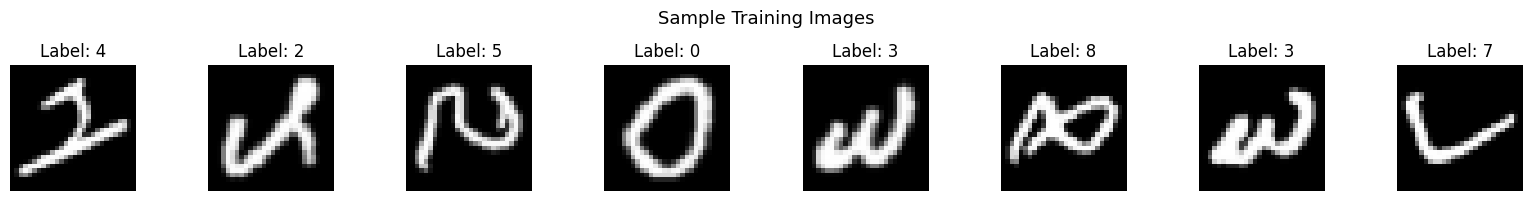

Batch shape : torch.Size([256, 1, 28, 28])
Pixel range : [0.00, 1.00]


In [26]:
# Quick sanity-check: display 8 raw images from the training set
samples, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Batch shape : {samples.shape}")   # (128, 1, 28, 28)
print(f"Pixel range : [{samples.min():.2f}, {samples.max():.2f}]")

In [7]:
class ANN_Shallow_BN32(nn.Module):
    """
    Fully-connected autoencoder.
    Encoder: 784 → 256 → 128 → 32
    Decoder: 32  → 128 → 256 → 784
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128,  32),             # ← bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear( 32, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def forward(self, x):
        z    = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

# Quick shape test
_m = ANN_Shallow_BN32().to(device)
_x = torch.randn(4, 1, 28, 28).to(device)
_out, _z = _m(_x)
print(f"✅ ANN_Shallow_BN32 | Input: {_x.shape} → Latent: {_z.shape} → Output: {_out.shape}")
del _m, _x, _out, _z

✅ ANN_Shallow_BN32 | Input: torch.Size([4, 1, 28, 28]) → Latent: torch.Size([4, 32]) → Output: torch.Size([4, 1, 28, 28])


In [8]:
class ANN_Deep_BN64(nn.Module):
    """
    Deeper fully-connected autoencoder with BatchNorm + Dropout.
    Encoder: 784 → 512 → 256 → 128 → 64
    Decoder: 64  → 128 → 256 → 512 → 784
    """
    def __init__(self, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128,  64),                                    # ← bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear( 64, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

_m = ANN_Deep_BN64().to(device)
_x = torch.randn(4, 1, 28, 28).to(device)
_out, _z = _m(_x)
print(f"✅ ANN_Deep_BN64    | Input: {_x.shape} → Latent: {_z.shape} → Output: {_out.shape}")
del _m, _x, _out, _z

✅ ANN_Deep_BN64    | Input: torch.Size([4, 1, 28, 28]) → Latent: torch.Size([4, 64]) → Output: torch.Size([4, 1, 28, 28])


In [9]:
class CNN_Linear_BN64(nn.Module):
    """
    Convolutional encoder → linear bottleneck → transposed-conv decoder.
    Spatial path: 28 → 14 → 7  (two MaxPool2d)
    Bottleneck  : flatten 32*7*7=1568 → Linear(64)
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),                                      # 28→14
            # Block 2
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                      # 14→7
            # Flatten → linear bottleneck
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),                           # ← bottleneck
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 32 * 7 * 7), nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            # Upsample 7→14
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            # Upsample 14→28
            nn.ConvTranspose2d(16,  1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

_m = CNN_Linear_BN64().to(device)
_x = torch.randn(4, 1, 28, 28).to(device)
_out, _z = _m(_x)
print(f"✅ CNN_Linear_BN64  | Input: {_x.shape} → Latent: {_z.shape} → Output: {_out.shape}")
del _m, _x, _out, _z

✅ CNN_Linear_BN64  | Input: torch.Size([4, 1, 28, 28]) → Latent: torch.Size([4, 64]) → Output: torch.Size([4, 1, 28, 28])


In [10]:
class CNN_Pure_BN32(nn.Module):
    """
    Fully convolutional autoencoder — NO linear layers.
    Bottleneck: 32 feature maps at 1x1 spatial resolution.
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d( 1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),                          # 28→14
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                          # 14→7
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                          # 7→3
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),             # 3→1  ✅ always exact 1x1
        )
        self.decoder = nn.Sequential(
            # 1→3
            nn.ConvTranspose2d(32, 64, 3, stride=1, padding=0),
            nn.BatchNorm2d(64), nn.ReLU(),
            # 3→7
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=0, output_padding=0),
            nn.BatchNorm2d(32), nn.ReLU(),
            # 7→14
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            # 14→28
            nn.ConvTranspose2d(16,  1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

# ✅ Verify shapes before training
_m = CNN_Pure_BN32().to(device)
_x = torch.randn(4, 1, 28, 28).to(device)
_out, _z = _m(_x)
print(f"✅ CNN_Pure_BN32 | Input: {_x.shape} → Latent: {_z.shape} → Output: {_out.shape}")
assert _out.shape == _x.shape, f"❌ Shape mismatch! {_out.shape} != {_x.shape}"
print("✅ Shape check passed!")
del _m, _x, _out, _z

✅ CNN_Pure_BN32 | Input: torch.Size([4, 1, 28, 28]) → Latent: torch.Size([4, 32, 1, 1]) → Output: torch.Size([4, 1, 28, 28])
✅ Shape check passed!


In [11]:
def ae_loss(x, x_hat):
    """
    Simple Binary Cross-Entropy reconstruction loss.
    x     : original image  (values in [0, 1])
    x_hat : reconstructed image (values in [0, 1])
    """
    return F.binary_cross_entropy(x_hat, x)

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best       = None
        self.stop       = False

    def __call__(self, val_loss):
        if self.best is None or val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train(model, name, epochs=30, lr=1e-3, patience=5):
    model.to(device)  # ✅ model to GPU
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)
    es = EarlyStopping(patience=patience)

    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        # ── Training ──────────────────────────────────────────────
        model.train()
        running = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)  # ✅ THIS is the critical fix
            opt.zero_grad()
            x_hat, z = model(imgs)
            loss = ae_loss(imgs, x_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()

        t_loss = running / len(train_loader)
        train_losses.append(t_loss)

        # ── Validation ────────────────────────────────────────────
        model.eval()
        running = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(device)  # ✅ val data to GPU too
                x_hat, z = model(imgs)
                running += ae_loss(imgs, x_hat).item()

        v_loss = running / len(val_loader)
        val_losses.append(v_loss)
        scheduler.step(v_loss)

        print(f"[{name}] Epoch {epoch:02d}/{epochs} | "
              f"Train {t_loss:.4f} | Val {v_loss:.4f} | "
              f"LR {opt.param_groups[0]['lr']:.2e}")

        es(v_loss)
        if es.stop:
            print(f"⏹  Early stopping at epoch {epoch}.")
            break

    return train_losses, val_losses

In [13]:
def plot_losses(history: dict):
    """history = {model_name: (train_losses, val_losses)}"""
    fig, axes = plt.subplots(1, len(history), figsize=(5 * len(history), 4))
    if len(history) == 1:
        axes = [axes]
    for ax, (name, (tl, vl)) in zip(axes, history.items()):
        ax.plot(tl, label="Train")
        ax.plot(vl, label="Val")
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle("Loss Curves", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def show_reconstructions(model, name, n=8):
    model.eval()
    imgs, _ = next(iter(val_loader))
    imgs    = imgs[:n].to(device)
    with torch.no_grad():
        recon, _ = model(imgs)
    imgs  = imgs.cpu().numpy()
    recon = recon.cpu().numpy()

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
    for i in range(n):
        axes[0, i].imshow(imgs[i, 0],  cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(recon[i, 0], cmap="gray"); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original",     fontsize=11)
    axes[1, 0].set_ylabel("Reconstructed",fontsize=11)
    plt.suptitle(f"{name} — Reconstructions", fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_latent_space(model, name, n_batches=10):
    """2-D t-SNE projection of the latent vectors (works for any bottleneck dim)."""
    from sklearn.manifold import TSNE
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(val_loader):
            if i >= n_batches: break
            _, z = model(imgs.to(device))
            zs.append(z.cpu().reshape(z.size(0), -1))   # flatten spatial dims for CNN_Pure
            ys.append(labels)
    Z = torch.cat(zs).numpy()
    Y = torch.cat(ys).numpy()

    print(f"Running t-SNE on {Z.shape[0]} samples, dim={Z.shape[1]} …")
    proj = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(Z)

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(proj[:, 0], proj[:, 1], c=Y, cmap="tab10", s=4, alpha=0.7)
    plt.colorbar(sc, label="Digit class")
    plt.title(f"{name} — Latent Space (t-SNE)", fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


  Training  →  ANN_Shallow_BN32
[ANN_Shallow_BN32] Epoch 01/100 | Train 0.2246 | Val 0.1729 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 02/100 | Train 0.1599 | Val 0.1524 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 03/100 | Train 0.1474 | Val 0.1438 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 04/100 | Train 0.1409 | Val 0.1386 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 05/100 | Train 0.1372 | Val 0.1358 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 06/100 | Train 0.1349 | Val 0.1343 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 07/100 | Train 0.1334 | Val 0.1327 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 08/100 | Train 0.1321 | Val 0.1314 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 09/100 | Train 0.1309 | Val 0.1304 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 10/100 | Train 0.1298 | Val 0.1295 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 11/100 | Train 0.1291 | Val 0.1287 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 12/100 | Train 0.1284 | Val 0.1280 | LR 1.00e-03
[ANN_Shallow_BN32] Epoch 13/100 | Train 0.1278 | Val 0.1276 | LR 1.00e-03
[ANN_

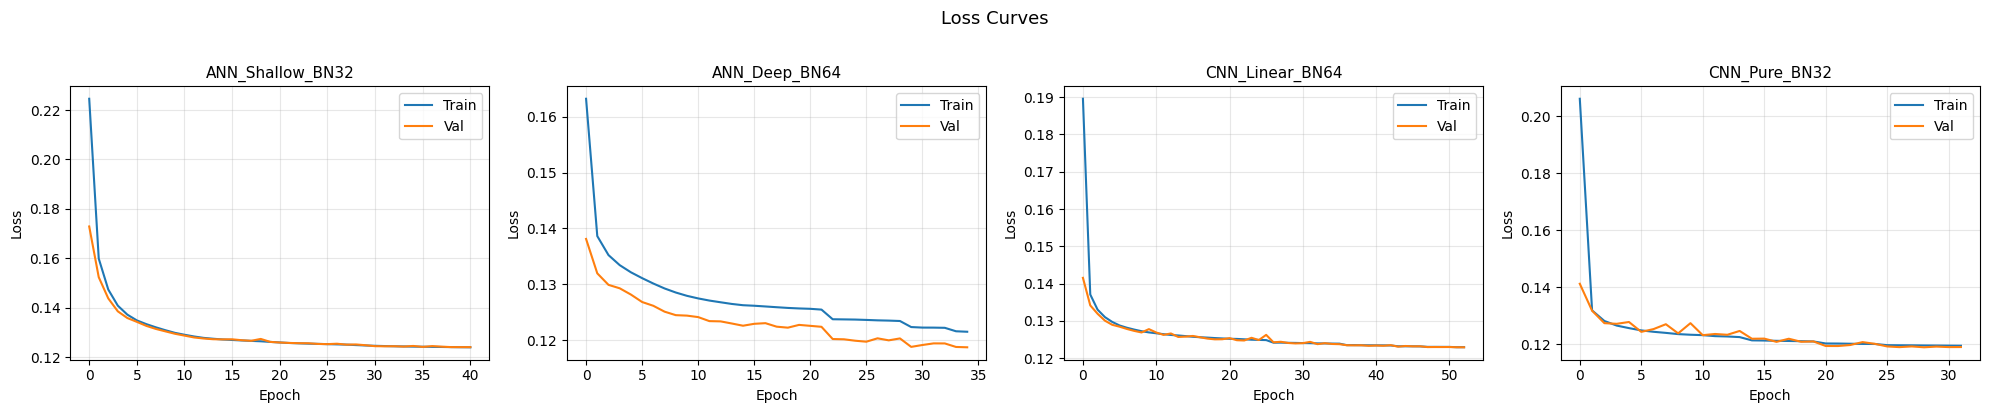

In [14]:
models = {
    "ANN_Shallow_BN32" : ANN_Shallow_BN32(),
    "ANN_Deep_BN64"    : ANN_Deep_BN64(),
    "CNN_Linear_BN64"  : CNN_Linear_BN64(),
    "CNN_Pure_BN32"    : CNN_Pure_BN32(),
}

history = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Training  →  {name}")
    print(f"{'='*55}")
    tl, vl = train(model, name, epochs=100, lr=1e-3, patience=5)
    history[name] = (tl, vl)


plot_losses(history)


── ANN_Shallow_BN32 ──


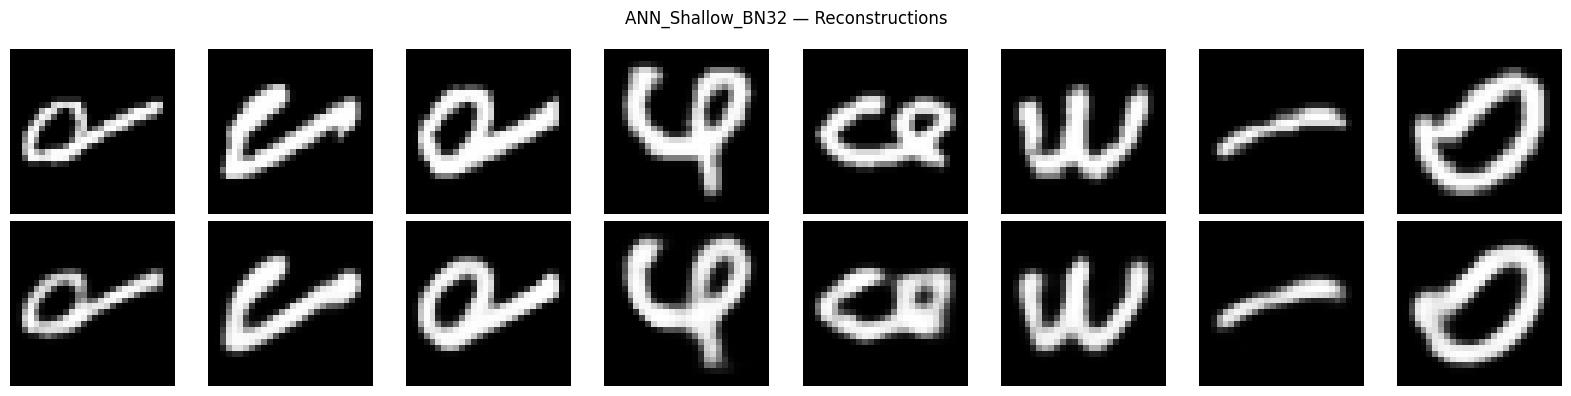

Running t-SNE on 2560 samples, dim=32 …


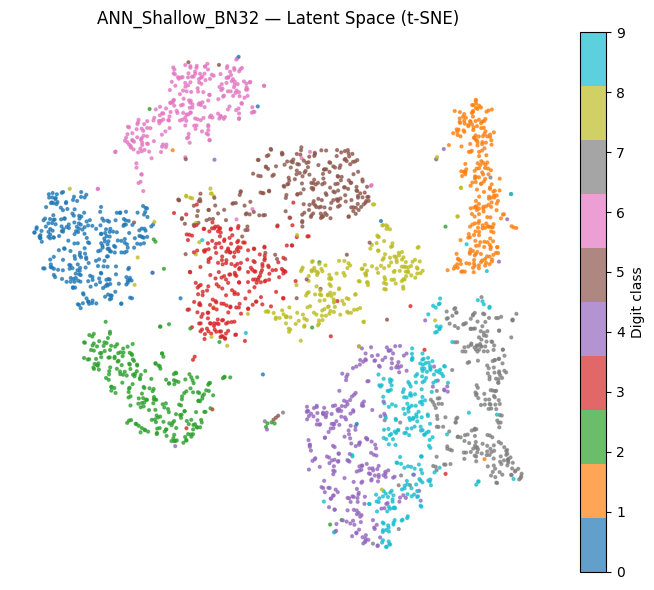


── ANN_Deep_BN64 ──


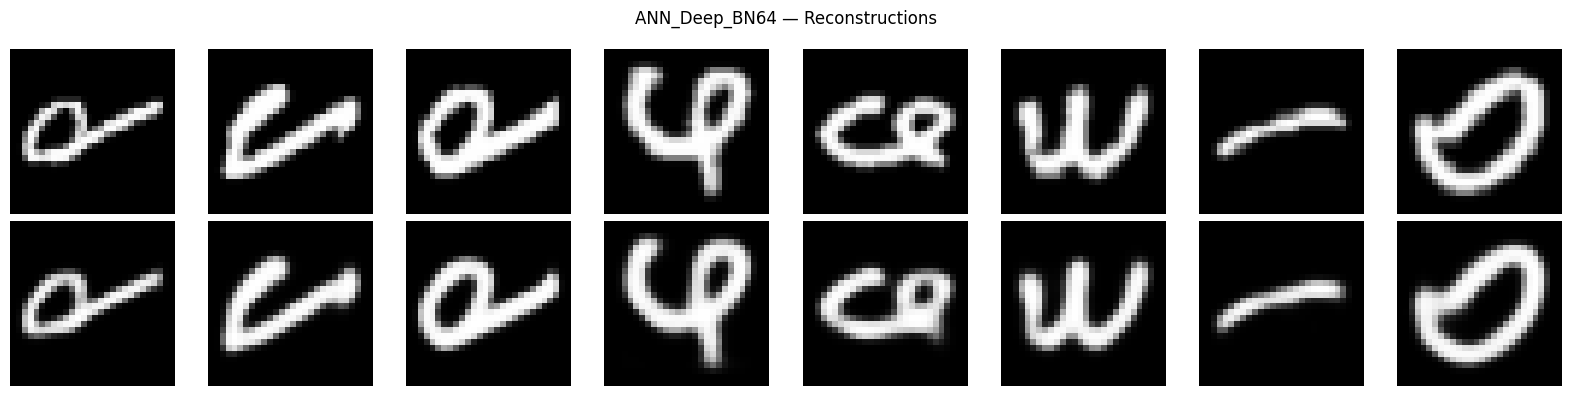

Running t-SNE on 2560 samples, dim=64 …


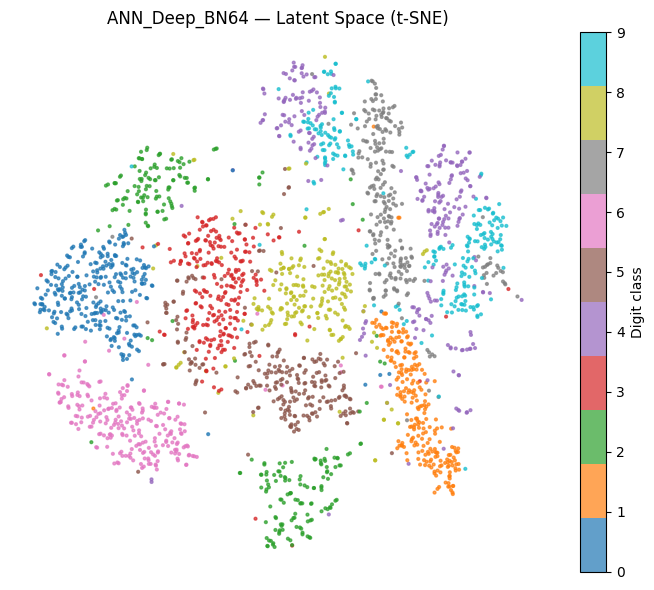


── CNN_Linear_BN64 ──


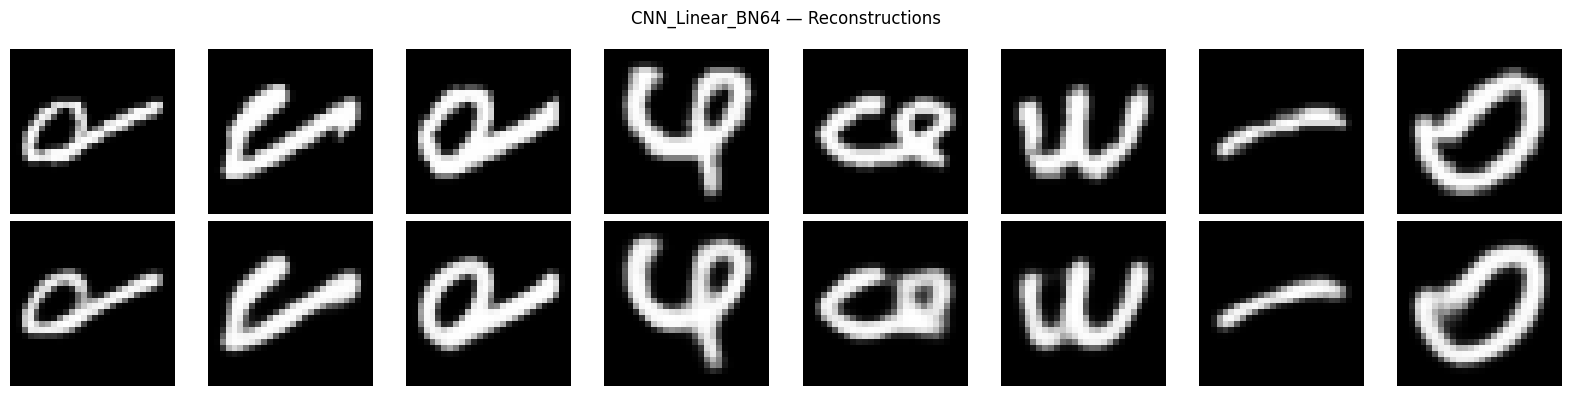

Running t-SNE on 2560 samples, dim=64 …


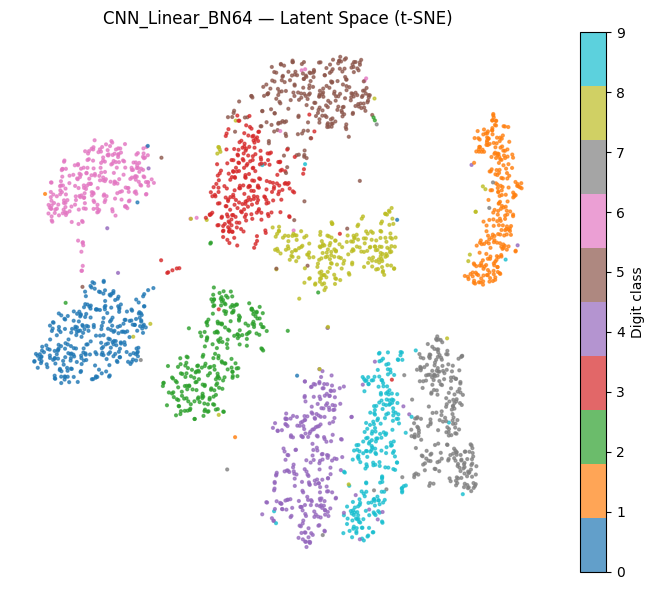


── CNN_Pure_BN32 ──


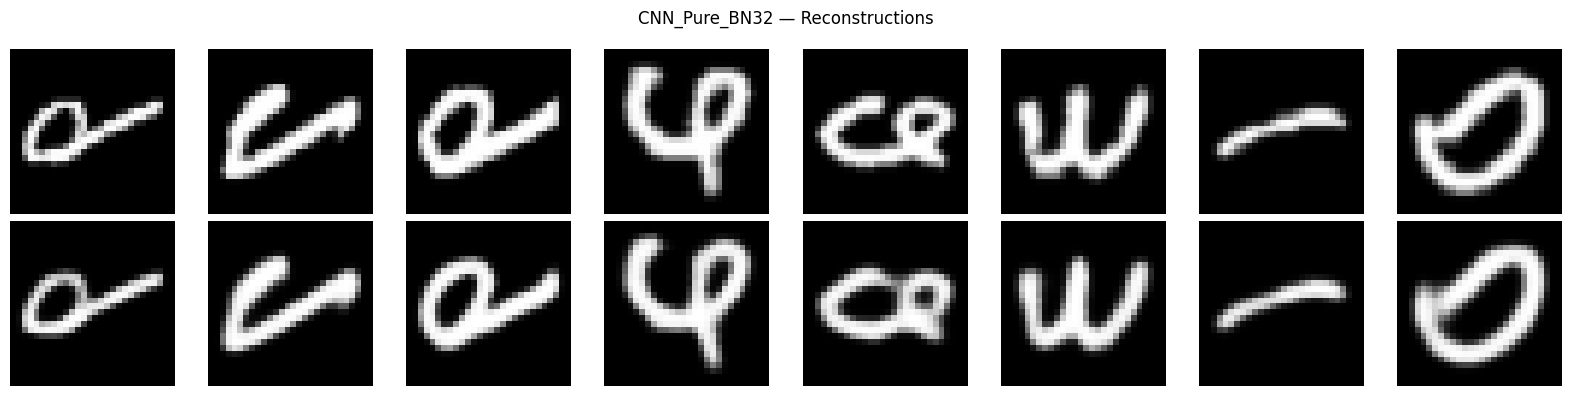

Running t-SNE on 2560 samples, dim=32 …


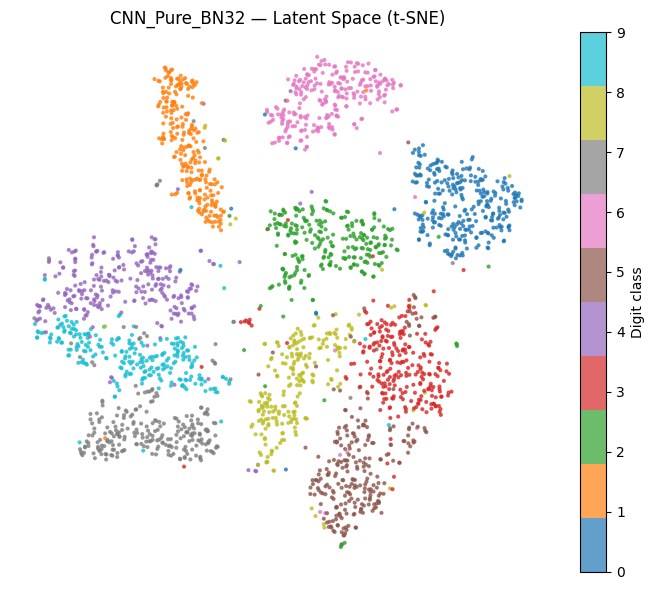

In [15]:
for name, model in models.items():
    print(f"\n── {name} ──")
    show_reconstructions(model, name)
    plot_latent_space(model, name)

NameError: name 'train_losses' is not defined